In [25]:
import re   
import random
import matplotlib.pyplot as plt  
from nltk.corpus import stopwords 
import numpy as np 

In [26]:
def preprocess(text):
    text = text.lower()
    words = re.findall(r'\b[a-z0-9]+\b', text)
    STOPWORDS = set(stopwords.words('english'))
    freq = {}

    for word in words:
        if word not in STOPWORDS:
            freq[word] = freq.get(word, 0) + 1

    return freq

In [27]:
def wordcloud(freq):
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    freq = sorted(freq.items(), key=lambda x:x[1], reverse=True)
    max_freq = freq[0][1]

    placed_boxes = []

    for word, count in freq:
        fontsize = 10+(count/max_freq)*60
        theta = 0
        placed = False

        while not placed and theta < 50:
            r = 0.02*theta
            x = 0.5 + r*np.cos(theta)
            y = 0.5 + r*np.sin(theta)

            box_x = fontsize/500
            box_y = fontsize/500

            overlap = False

            for px, py, pbx, pby in placed_boxes:
                if abs(x-px) < abs(box_x+pbx) and abs(y-py) < abs(box_y+pby):
                    overlap = True
                    break
                
            if not overlap:
                plt.text(x, y, word, fontsize=fontsize, va='center', ha='center', color=(random.random(), random.random(), random.random()))
                placed_boxes.append([x, y, box_x, box_y])
                placed = True

            theta += 0.3

        if not placed:
            x = random.uniform(0.2, 0.8)
            y = random.uniform(0.2, 0.8)
            plt.text(x, y, word, fontsize=fontsize, va='center', ha='center', color=(random.random(), random.random(), random.random()))

    plt.show()

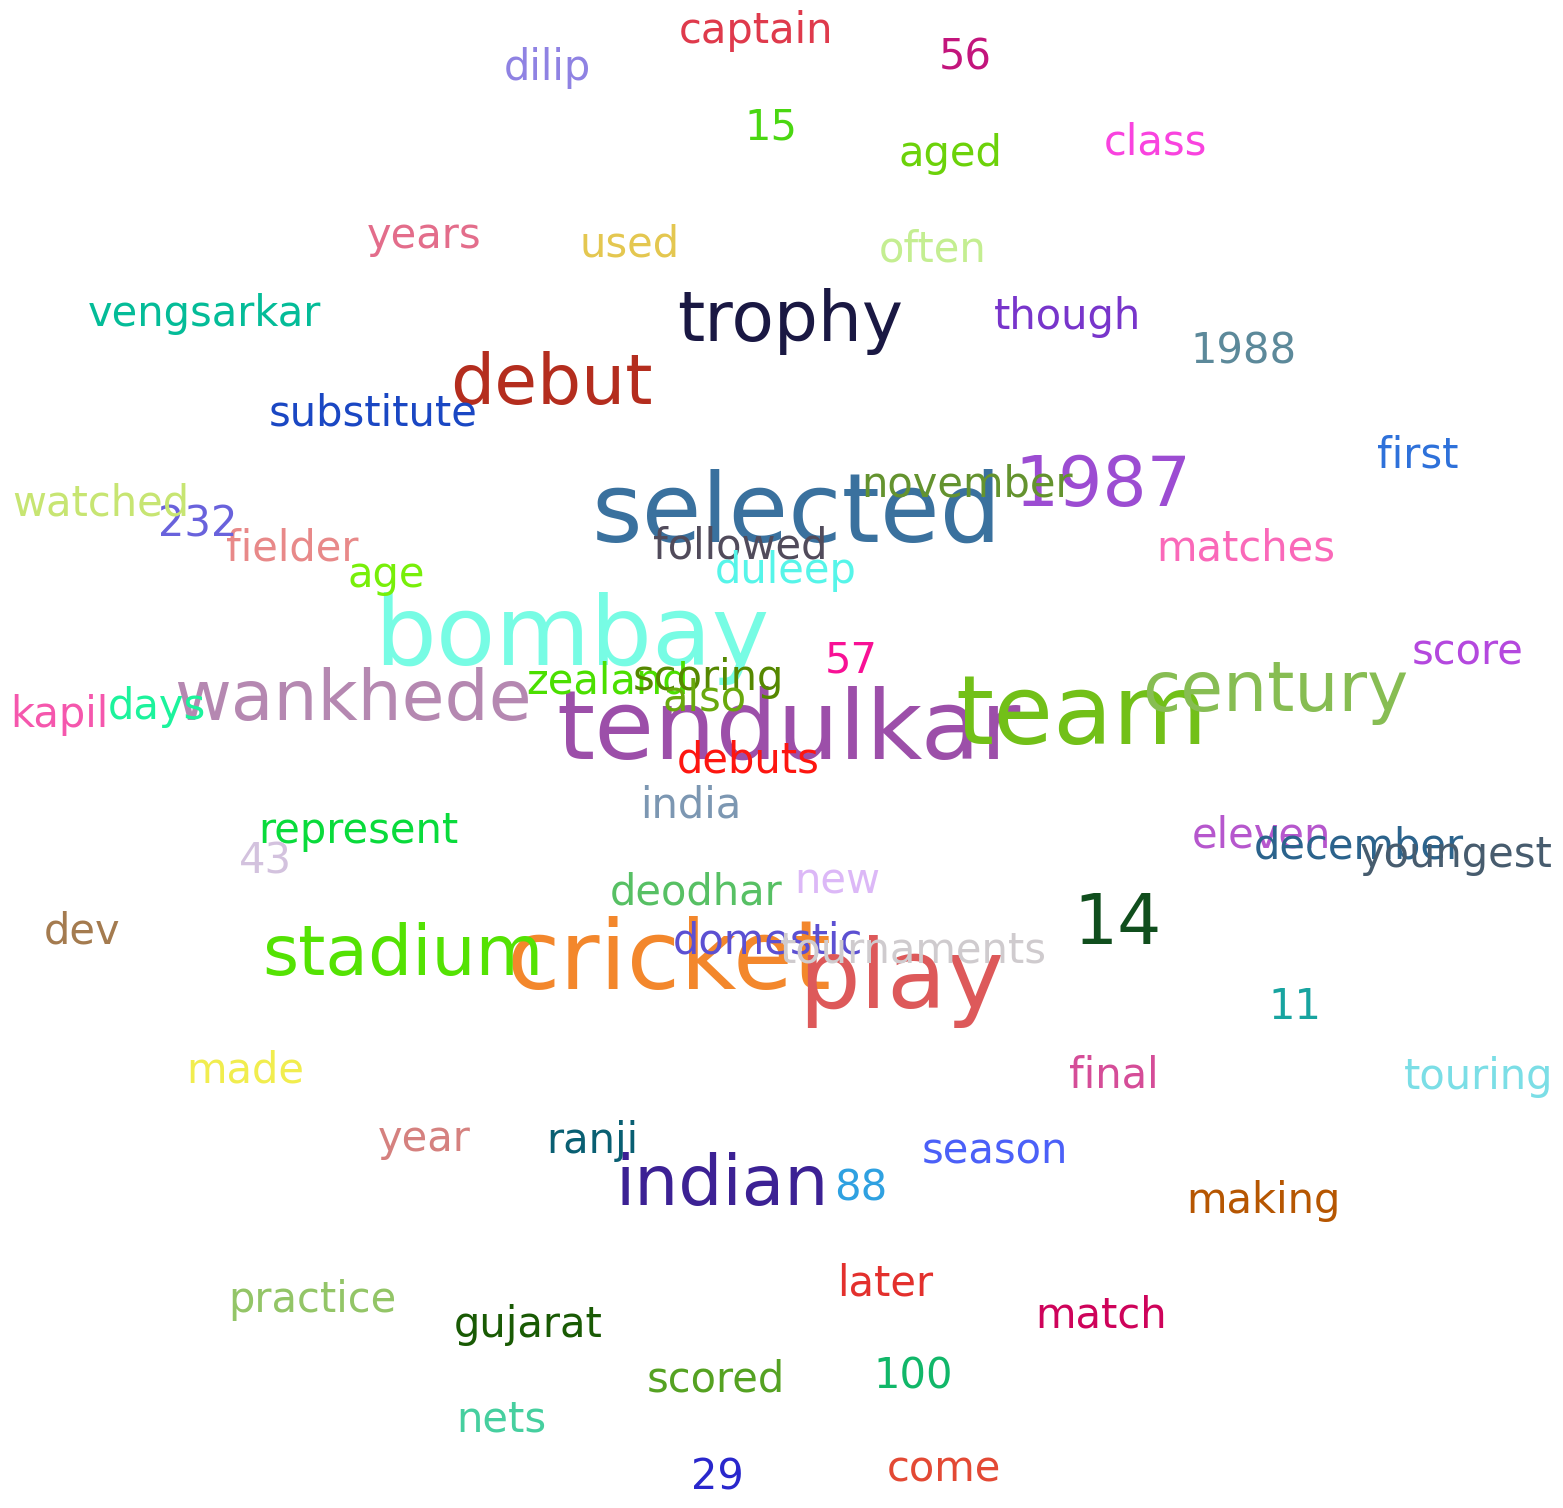

In [28]:
text="""On 14 November 1987, at age 14, Tendulkar was selected to represent Bombay in the Ranji Trophy for the 1987–88 season, but he was not selected for the final eleven in any of the matches, though he was often used as a substitute fielder.[43] A year later, on 11 December 1988, aged 15 years and 232 days, Tendulkar made his debut for Bombay against Gujarat at Wankhede Stadium and scored 100 (not out) in that match, making him the youngest Indian to score a century on debut in first-class cricket.[56] He was selected to play for the team by Bombay captain Dilip Vengsarkar, who watched him play Kapil Dev in Wankhede Stadium's cricket practice nets,[29] where the Indian team had come to play against the touring New Zealand team. Tendulkar followed this by scoring a century each in his Deodhar and Duleep Trophy debuts, which are also India's domestic cricket tournaments.[57]
"""
wordcloud(preprocess(text))